# Credit Card Fraud Alert Ranking — Cost-Aware Offline Evaluation

**Author:** Leonardo Flores · [LinkedIn](https://www.linkedin.com/in/leonardo-floresg/) · [GitHub](https://github.com/Luthiax)

> **Evidence boundary:** this is an offline case study on an anonymized 48-hour historical sample. It is not a real-time system, deployment approval, or proof of future bank savings.

## Decision question

How should a limited review queue prioritize rare fraud alerts, and how can a threshold be selected without contaminating the final evaluation?

## 1. Data quality and class imbalance

In [1]:
import pandas as pd
from IPython.display import Image, display

from run_analysis import load_data, run_analysis

df = load_data()
pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "fraud_cases": int(df["Class"].sum()),
    "fraud_rate": df["Class"].mean(),
    "missing_cells": int(df.isna().sum().sum()),
    "time_span_hours": (df["Time"].max() - df["Time"].min()) / 3600,
    "mean_fraud_amount_eur": df.loc[df["Class"] == 1, "Amount"].mean(),
})

rows                     284807.000000
columns                      31.000000
fraud_cases                 492.000000
fraud_rate                    0.001727
missing_cells                 0.000000
time_span_hours              47.997778
mean_fraud_amount_eur       122.211321
dtype: float64

A classifier that predicts every transaction as legitimate would be about 99.83% accurate while catching no fraud. The useful questions are ranking quality, fraud captured within review capacity, alert precision, and cost under explicit assumptions.

## 2. Evaluation design

Transactions are sorted by `Time` and split into three non-overlapping periods:

- earliest 60%: model fitting and internal probability calibration;
- next 20%: champion selection and threshold selection;
- latest 20%: one final evaluation after all choices are frozen.

The 48-hour window is too short for robust drift testing, but this design is more deployment-like than a random split and prevents the final test from being reused for tuning.

In [2]:
result = run_analysis()
result["split_summary"]

,partition,rows,frauds,fraud_rate,start_time,end_time
0,train,170882,360,0.002107,0.0,120395.0
1,validation,56963,57,0.001001,120396.0,145247.0
2,test,56962,75,0.001317,145248.0,172792.0


## 3. Model selection on validation only

Calibrated class-weighted Logistic Regression provides a transparent baseline. Calibrated XGBoost tests whether nonlinear interactions materially improve ranking. The champion is selected by validation PR-AUC; Recall@100 shows how much fraud is captured by a fixed review capacity.

In [3]:
result["validation_results"]

,model,validation_pr_auc,validation_recall_at_100
1,XGBoost,0.783034,0.789474
0,Logistic Regression,0.748611,0.771930


## 4. Cost threshold selected before final test

For a threshold `t`:

```text
review cost = number of alerts × EUR 5
missed fraud loss = sum(Amount for false negatives) × 1.0
total cost = review cost + missed fraud loss
```

Every alert incurs review cost, including true positives. The loss calculation uses the actual amount of each missed fraud in the evaluation period. These are still illustrative assumptions: transaction amount may not equal net loss, caught fraud may not be fully prevented, and real review cost may differ.

In [4]:
pd.Series(result["test_summary"])

champion_model                                XGBoost
selected_validation_threshold                   0.569
test_pr_auc                                  0.801263
test_recall_at_100                           0.773333
threshold                                       0.569
alerts                                             61
alert_rate                                   0.001071
true_positives                                     57
false_positives                                     4
false_negatives                                    18
precision                                    0.934426
recall                                           0.76
review_cost_eur                                 305.0
missed_fraud_loss_eur                         2638.27
total_cost_eur                                2943.27
review_nothing_eur                            7729.26
review_everything_eur                        284810.0
savings_vs_review_nothing_eur                 4785.99
savings_vs_review_everything

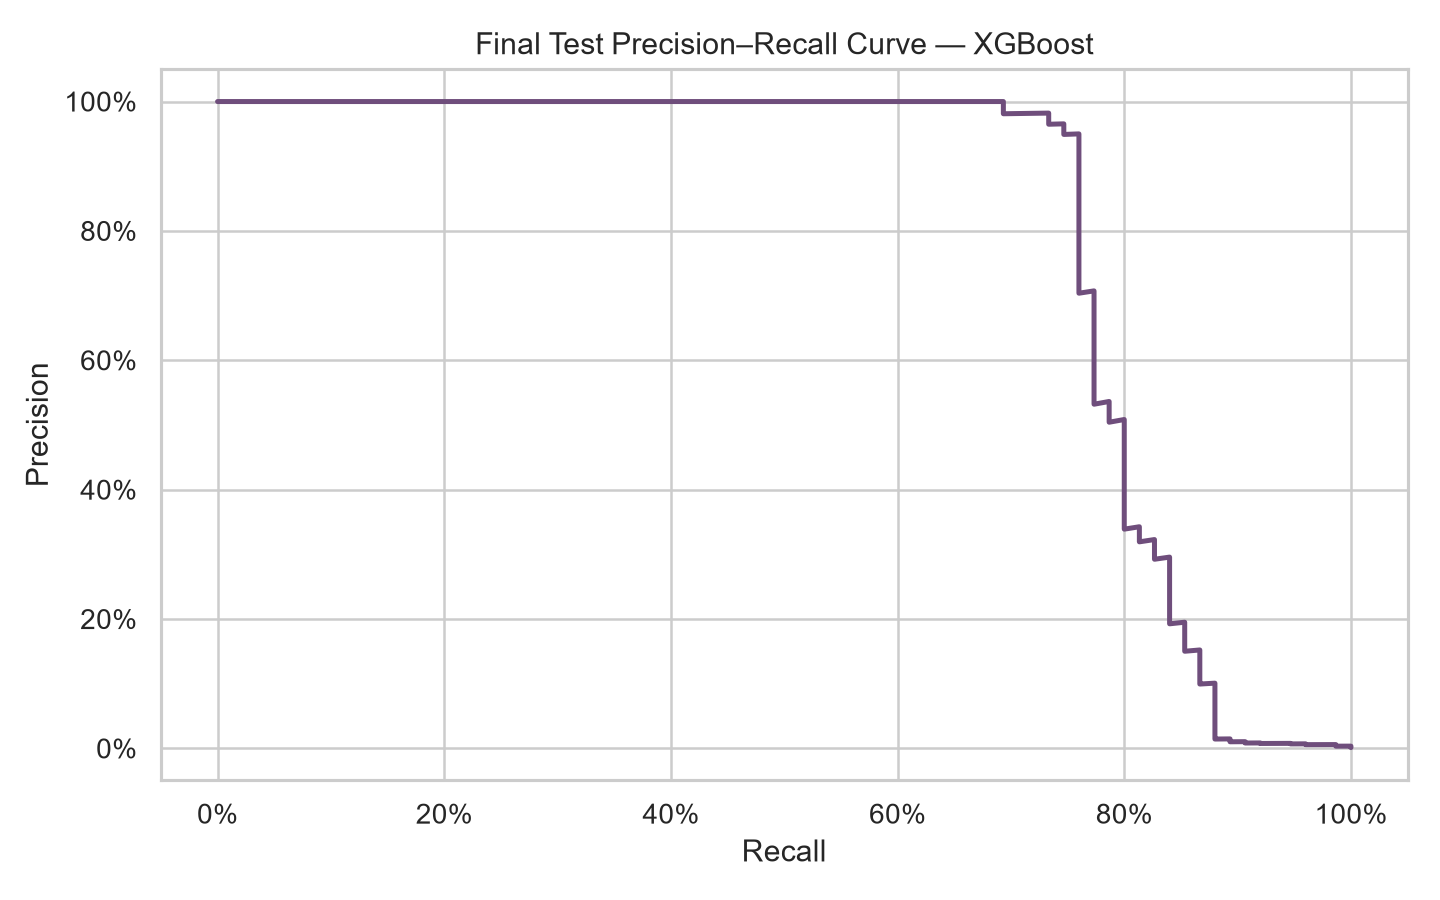

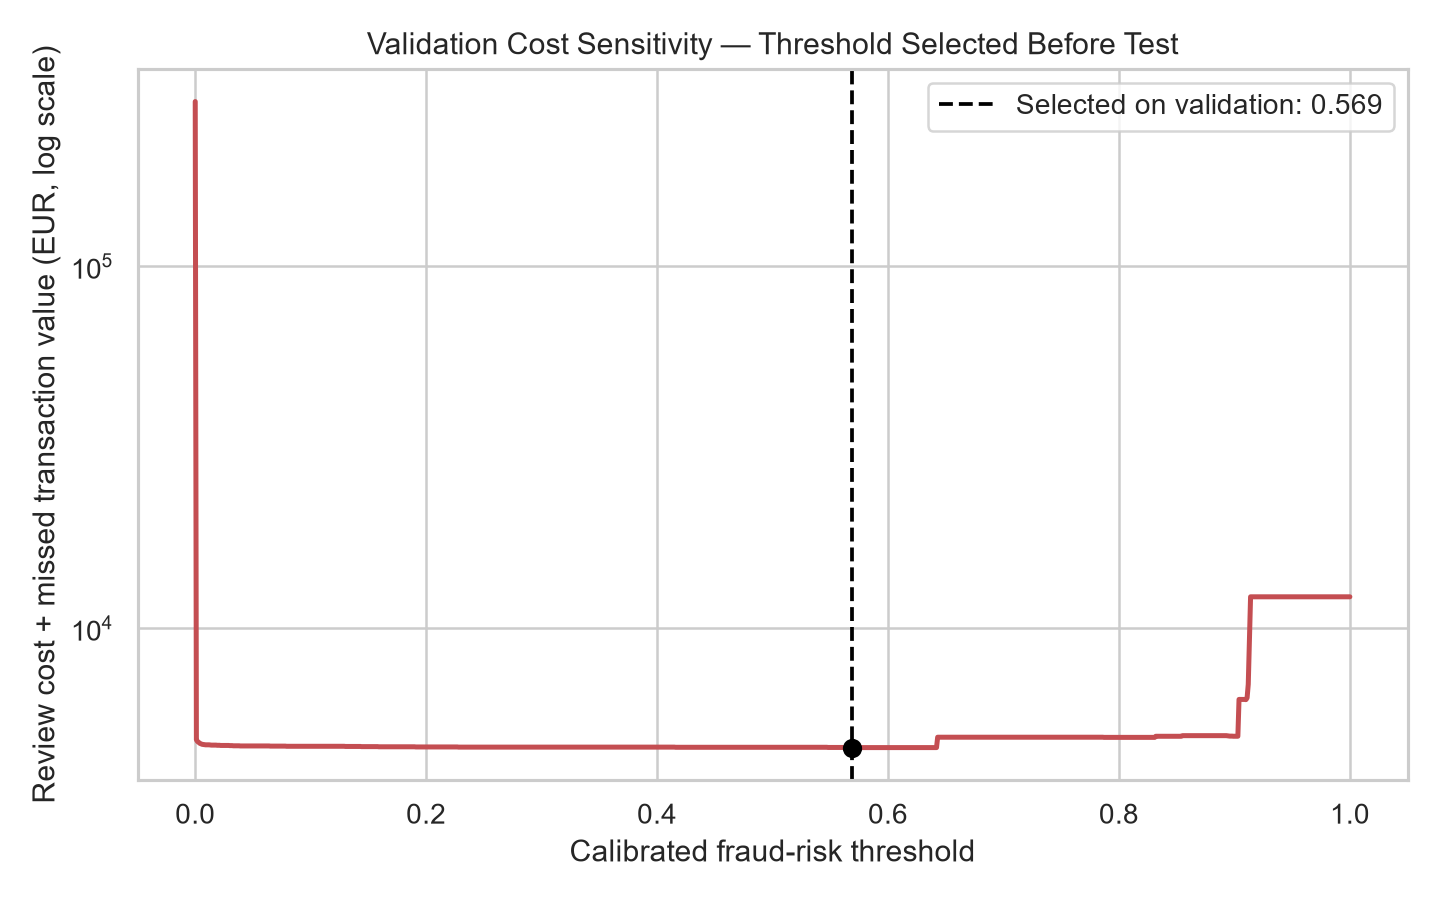

In [5]:
display(Image(filename="screenshots/pr_curve.png"))
display(Image(filename="screenshots/cost_curve.png"))

## 5. Interpretation and recommendation

A defensible result reports the final-test PR-AUC, Recall@100, alert rate, precision, recall, TP/FP/FN counts, total cost, and separate comparisons with reviewing nothing and reviewing everything. It does not call PCA features causal or operationally actionable.

The appropriate next step would be shadow-mode validation with current, institution-specific data and costs. Auto-decline is not supported by this case study. Any production proposal would also need latency testing, label-delay handling, drift monitoring, account-level leakage controls, customer-friction costs, and compliance review.